# Módulo 4: Clasificación — Predicción de Churn

## ¿Qué aprenderás en este notebook?

La **clasificación** es uno de los tipos de aprendizaje supervisado más utilizados. A diferencia de la regresión (que predice un valor continuo), la clasificación predice a cuál **categoría** pertenece una observación.

### Problema de negocio
> Una empresa de telecomunicaciones quiere predecir **qué clientes van a cancelar su suscripción** (churn). Identificarlos con anticipación permite tomar acciones preventivas como descuentos u ofertas especiales.

### Flujo de trabajo
```
Datos → Exploración → Preparación → Features → Modelo → Evaluación → Interpretación
```

### Contenido
1. 📦 Dataset de churn (simulado)
2. 🧹 Preparación de datos y splits
3. 🔍 Análisis de importancia de features
4. 📐 Teoría: regresión logística y función sigmoide
5. 🤖 Entrenamiento con scikit-learn
6. 📊 Interpretación de coeficientes y predicción

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer  # Encoding de variables categóricas
from sklearn.linear_model import LogisticRegression     # Modelo de clasificación
from sklearn.metrics import accuracy_score, roc_auc_score, mutual_info_score
from sklearn.dummy import DummyClassifier               # Modelo base de comparación

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Dataset de Churn

### ¿Qué es el churn?
**Churn** (o "fuga de clientes") ocurre cuando un cliente deja de usar el servicio de una empresa. Es un problema de **clasificación binaria**:
- `churn = 1` → el cliente canceló
- `churn = 0` → el cliente sigue activo

### Variable objetivo (target)
En clasificación, la variable que queremos predecir se llama **target** o etiqueta. Aquí es `churn`.

### Features disponibles
| Feature | Tipo | Descripción |
|---|---|---|
| `gender` | Categórica | Género del cliente |
| `tenure` | Numérica | Meses como cliente |
| `contract` | Categórica | Tipo de contrato |
| `monthly_charges` | Numérica | Cargo mensual |
| `internet_service` | Categórica | Tipo de internet |
| `online_security` | Categórica | Tiene seguridad online |
| `tech_support` | Categórica | Tiene soporte técnico |
| `payment_method` | Categórica | Método de pago |
| `total_charges` | Numérica | Cargo total acumulado |

> **Nota:** Simulamos los datos con una lógica realista: contratos cortos, fibra óptica y pago con cheque electrónico aumentan la probabilidad de churn.

In [15]:
# ─── Crear dataset sintético de churn ───────────────────────────────────────
# Simulamos 2000 clientes con características reales de una empresa de telecom

n = 2000
np.random.seed(42)

df = pd.DataFrame({
    'gender': np.random.choice(['Male', 'Female'], n),
    'tenure': np.random.randint(1, 72, n),                                     # 1 a 72 meses
    'contract': np.random.choice(
        ['Month-to-month', 'One year', 'Two year'], n, p=[0.5, 0.3, 0.2]       # contratos mensuales son más frecuentes
    ),
    'monthly_charges': np.random.uniform(20, 100, n).round(2),
    'internet_service': np.random.choice(
        ['DSL', 'Fiber optic', 'No'], n, p=[0.35, 0.45, 0.2]
    ),
    'online_security': np.random.choice(
        ['Yes', 'No', 'No internet'], n, p=[0.3, 0.5, 0.2]
    ),
    'tech_support': np.random.choice(
        ['Yes', 'No', 'No internet'], n, p=[0.3, 0.5, 0.2]
    ),
    'payment_method': np.random.choice(
        ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n
    ),
})

# Total de cargos = cargos mensuales × meses como cliente
df['total_charges'] = (df['monthly_charges'] * df['tenure']).round(2)

# ─── Generar churn con lógica de negocio realista ────────────────────────────
# Cada factor suma o resta probabilidad de churn
prob_churn = (
    0.1                                                              # probabilidad base
    + 0.3  * (df['contract'] == 'Month-to-month')                   # contrato mensual → más riesgo
    - 0.15 * (df['contract'] == 'Two year')                         # contrato largo → menos riesgo
    - 0.005 * df['tenure']                                          # más antiguo → más fidelizado
    + 0.003 * df['monthly_charges']                                 # cobros altos → más riesgo
    + 0.1  * (df['internet_service'] == 'Fiber optic')              # fibra óptica → más riesgo (quizás por precio)
    - 0.1  * (df['online_security'] == 'Yes')                       # seguridad online → retiene clientes
    + 0.05 * (df['payment_method'] == 'Electronic check')           # cheque electrónico → más riesgo
)

# Limitar probabilidades al rango [0.05, 0.95] para evitar valores extremos
prob_churn = prob_churn.clip(0.05, 0.95)

# Generar churn: muestra aleatoria basada en la probabilidad calculada
df['churn'] = (np.random.random(n) < prob_churn).astype(int)

print(f"Dataset: {df.shape[0]} clientes, {df.shape[1]} columnas")
print(f"Tasa de churn: {df['churn'].mean():.2%}  (clientes que cancelaron)")
df.head()

Dataset: 2000 clientes, 10 columnas
Tasa de churn: 26.70%  (clientes que cancelaron)


,gender,tenure,contract,monthly_charges,internet_service,online_security,tech_support,payment_method,total_charges,churn
0,Male,47,Month-to-month,51.89,Fiber optic,Yes,No,Bank transfer,2438.83,0
1,Female,12,One year,89.03,Fiber optic,Yes,Yes,Credit card,1068.36,0
2,Male,62,Month-to-month,41.37,Fiber optic,Yes,No internet,Credit card,2564.94,1
3,Male,8,Two year,62.77,DSL,No,Yes,Electronic check,502.16,0
4,Male,21,Two year,88.70,DSL,No internet,No internet,Bank transfer,1862.70,0


## 2. Preparación de datos

### ¿Por qué dividir en conjuntos?

Para evaluar correctamente un modelo de clasificación necesitamos separar los datos en **tres conjuntos**:

| Conjunto | Uso | Tamaño típico |
|---|---|---|
| **Train** | Entrenar el modelo (ajustar parámetros) | 60% |
| **Validación** | Ajustar hiperparámetros y comparar modelos | 20% |
| **Test** | Evaluación final (simula datos nuevos) | 20% |

> **Regla clave:** El modelo **nunca debe ver** el conjunto de test durante el entrenamiento ni la selección del modelo. Usarlo antes contamina la evaluación.

### ¿Por qué separar el target (y)?
El modelo aprende la relación entre features (X) y el target (y). Si el target queda en X, el modelo haría trampa al entrenarse.

In [16]:
# ─── Dividir datos en Train / Validación / Test ──────────────────────────────
# Paso 1: separar el 20% para test final
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Paso 2: del 80% restante, usar el 25% para validación → equivale al 20% del total
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=42)

# ─── Extraer el target (y) de cada conjunto ──────────────────────────────────
y_train = df_train['churn'].values
y_val   = df_val['churn'].values
y_test  = df_test['churn'].values

# Eliminar el target de los dataframes de features para evitar fuga de información
df_train = df_train.drop(columns=['churn'])
df_val   = df_val.drop(columns=['churn'])
df_test  = df_test.drop(columns=['churn'])

print(f"Tamaños → Train: {len(df_train)}, Validación: {len(df_val)}, Test: {len(df_test)}")
print(f"Tasa de churn en train: {y_train.mean():.2%}")
print(f"Tasa de churn en val:   {y_val.mean():.2%}")
print()
print("✅ Los tres conjuntos tienen distribuciones similares de churn (buena señal)")
print("   Esto ocurre porque train_test_split mezcla aleatoriamente los datos.")

Tamaños → Train: 1200, Validación: 400, Test: 400
Tasa de churn en train: 26.08%
Tasa de churn en val:   26.75%

✅ Los tres conjuntos tienen distribuciones similares de churn (buena señal)
   Esto ocurre porque train_test_split mezcla aleatoriamente los datos.


In [17]:
# ─── Identificar tipos de variables ──────────────────────────────────────────
# Las variables categóricas y numéricas requieren tratamiento diferente

categoricas = df_train.select_dtypes(include='object').columns.tolist()
numericas   = df_train.select_dtypes(include='number').columns.tolist()

print(f"Variables categóricas ({len(categoricas)}): {categoricas}")
print(f"Variables numéricas   ({len(numericas)}):   {numericas}")
print()
print("Las categóricas necesitan encoding (convertir texto → números)")
print("Las numéricas se pueden usar directamente (o normalizar)")

Variables categóricas (6): ['gender', 'contract', 'internet_service', 'online_security', 'tech_support', 'payment_method']
Variables numéricas   (3):   ['tenure', 'monthly_charges', 'total_charges']

Las categóricas necesitan encoding (convertir texto → números)
Las numéricas se pueden usar directamente (o normalizar)


/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_2244/2076944360.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df_train.select_dtypes(include='object').columns.tolist()


## 3. Importancia de Features

### ¿Por qué analizar features antes de modelar?

Antes de entrenar, conviene entender **qué tan útil es cada variable** para predecir el target. Esto nos ayuda a:
- Detectar variables informativas vs. ruidosas
- Entender el problema de negocio
- Reducir dimensionalidad si es necesario

### Herramientas que usaremos

**1. Risk Ratio (Tasa de Riesgo)**
Para variables categóricas, calculamos la tasa de churn por categoría y la comparamos con la tasa global:

$$RR = \frac{\text{tasa de churn en categoría}}{\text{tasa global de churn}}$$

- `RR > 1` → esa categoría tiene **más riesgo** de churn que el promedio
- `RR < 1` → esa categoría tiene **menos riesgo** que el promedio
- `RR ≈ 1` → la categoría no informa sobre churn

**2. Información Mutua (Mutual Information)**
Mide cuánta información comparte una variable categórica con el target. A mayor valor, más útil es la variable.

**3. Correlación de Pearson**
Para variables numéricas: correlación entre la feature y el target binario (0/1).

In [18]:
# ─── Risk Ratio por variable categórica ─────────────────────────────────────
# Comparamos la tasa de churn en cada grupo con la tasa global

tasa_global = y_train.mean()
print(f"Tasa global de churn: {tasa_global:.2%}  ← línea de referencia\n")

for col in categoricas:
    print(f"{'─'*50}")
    print(f" {col}")
    for val in sorted(df_train[col].unique()):
        mask = df_train[col] == val
        tasa = y_train[mask.values].mean()
        rr   = tasa / tasa_global
        # Indicador visual: ▲ riesgo alto, ▼ riesgo bajo, ─ neutral
        indicador = "▲ RIESGO" if rr > 1.1 else ("▼ protege" if rr < 0.9 else "─ neutral")
        print(f"    {val:<25}: churn={tasa:.2%}  RR={rr:.2f}  {indicador}")
    print()

print("Interpretación: 'contract=Month-to-month' tiene RR > 1.5,")
print("   significa que esos clientes churnan 50% más que el promedio.")

Tasa global de churn: 26.08%  ← línea de referencia

──────────────────────────────────────────────────
 gender
    Female                   : churn=27.56%  RR=1.06  ─ neutral
    Male                     : churn=24.72%  RR=0.95  ─ neutral

──────────────────────────────────────────────────
 contract
    Month-to-month           : churn=40.36%  RR=1.55  ▲ RIESGO
    One year                 : churn=11.67%  RR=0.45  ▼ protege
    Two year                 : churn=11.16%  RR=0.43  ▼ protege

──────────────────────────────────────────────────
 internet_service
    DSL                      : churn=22.44%  RR=0.86  ▼ protege
    Fiber optic              : churn=32.01%  RR=1.23  ▲ RIESGO
    No                       : churn=19.85%  RR=0.76  ▼ protege

──────────────────────────────────────────────────
 online_security
    No                       : churn=27.60%  RR=1.06  ─ neutral
    No internet              : churn=31.28%  RR=1.20  ▲ RIESGO
    Yes                      : churn=20.17%  RR=0.

Información Mutua con 'churn' (mayor = más informativa):
  contract            : 0.0568  █████████████████
  internet_service    : 0.0074  ██
  online_security     : 0.0044  █
  payment_method      : 0.0023  
  tech_support        : 0.0007  
  gender              : 0.0005  


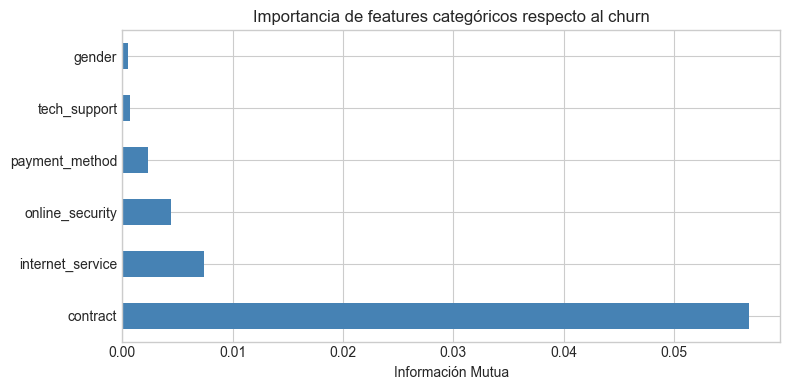


💡 'contract' domina: el tipo de contrato es el predictor más informativo.


In [19]:
# ─── Información Mutua (Mutual Information) ──────────────────────────────────
# Cuantifica cuánto "sabe" cada variable categórica sobre el target
# Ventaja: captura relaciones no lineales, a diferencia de la correlación

mi_scores = {}
for col in categoricas:
    mi_scores[col] = mutual_info_score(df_train[col], y_train)

mi_df = pd.Series(mi_scores).sort_values(ascending=False)

print("Información Mutua con 'churn' (mayor = más informativa):")
for col, score in mi_df.items():
    barra = '█' * int(score * 300)
    print(f"  {col:<20}: {score:.4f}  {barra}")

# Visualización
mi_df.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.xlabel('Información Mutua')
plt.title('Importancia de features categóricos respecto al churn')
plt.tight_layout()
plt.show()

print("\n💡 'contract' domina: el tipo de contrato es el predictor más informativo.")

In [20]:
# ─── Correlación de features numéricas con churn ─────────────────────────────
# La correlación de Pearson mide la relación lineal entre -1 y +1
#   +1 → correlación positiva perfecta
#   -1 → correlación negativa perfecta
#    0 → sin relación lineal

print("Correlación de Pearson con 'churn':")
print()
for col in numericas:
    corr = np.corrcoef(df_train[col].values, y_train)[0, 1]
    direccion = "↑ más churn" if corr > 0 else "↓ menos churn"
    print(f"  {col:<20}: {corr:+.3f}  ({direccion} a mayor valor)")

print()
print("💡 Tenure negativo: clientes con más tiempo tienen MENOS probabilidad de churn.")
print("   Esto tiene sentido: la fidelidad crece con el tiempo.")

Correlación de Pearson con 'churn':

  tenure              : -0.152  (↓ menos churn a mayor valor)
  monthly_charges     : +0.083  (↑ más churn a mayor valor)
  total_charges       : -0.072  (↓ menos churn a mayor valor)

💡 Tenure negativo: clientes con más tiempo tienen MENOS probabilidad de churn.
   Esto tiene sentido: la fidelidad crece con el tiempo.


## 4. Regresión Logística

### ¿Por qué no usar regresión lineal para clasificar?

La regresión lineal predice valores continuos (cualquier número), pero para clasificación necesitamos **probabilidades entre 0 y 1**. Una predicción de 1.7 o -0.3 no tiene sentido como probabilidad.

### La función sigmoide (σ)

La regresión logística resuelve esto aplicando la **función sigmoide** a la combinación lineal de features:

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

donde:
- $z = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$ (combinación lineal)
- $\hat{p}$ es la probabilidad estimada de que $y = 1$ (churn)

### Propiedades clave de la sigmoide
- Salida **siempre entre 0 y 1** ✅
- Cuando $z = 0$ → $\hat{p} = 0.5$ (incertidumbre máxima)
- Cuando $z → +\infty$ → $\hat{p} → 1$ (casi seguro churn)
- Cuando $z → -\infty$ → $\hat{p} → 0$ (casi seguro no churn)

### Regla de decisión
$$\text{predicción} = \begin{cases} 1 & \text{si } \hat{p} \geq 0.5 \\ 0 & \text{si } \hat{p} < 0.5 \end{cases}$$

> El umbral de 0.5 se puede ajustar según el costo del negocio (ej: si es más grave no detectar un churn real, se baja el umbral).

/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_2244/4205969048.py:22: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/mdurango/Downloads/proyectos/machine-learning-zoomcamp/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


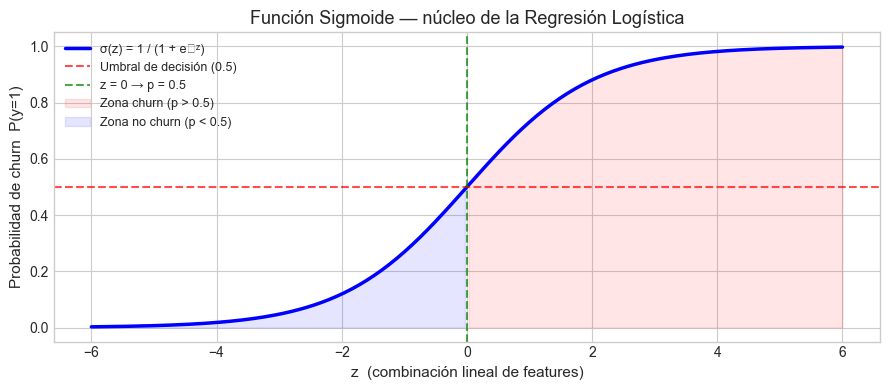

La curva en S transforma z (−∞, +∞) en una probabilidad [0, 1].


In [21]:
# ─── Visualizar la función sigmoide ──────────────────────────────────────────
def sigmoide(z):
    """Función sigmoide: transforma cualquier número real a [0, 1]."""
    return 1 / (1 + np.exp(-z))

z = np.linspace(-6, 6, 200)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z, sigmoide(z), 'b-', lw=2.5, label='σ(z) = 1 / (1 + e⁻ᶻ)')
ax.axhline(y=0.5, color='red',   linestyle='--', alpha=0.7, label='Umbral de decisión (0.5)')
ax.axvline(x=0,   color='green', linestyle='--', alpha=0.7, label='z = 0 → p = 0.5')

# Zonas de decisión
ax.fill_between(z, 0, sigmoide(z), where=(z > 0), alpha=0.1, color='red',  label='Zona churn (p > 0.5)')
ax.fill_between(z, 0, sigmoide(z), where=(z < 0), alpha=0.1, color='blue', label='Zona no churn (p < 0.5)')

ax.set_xlabel('z  (combinación lineal de features)', fontsize=11)
ax.set_ylabel('Probabilidad de churn  P(y=1)', fontsize=11)
ax.set_title('Función Sigmoide — núcleo de la Regresión Logística', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("La curva en S transforma z (−∞, +∞) en una probabilidad [0, 1].")

## 5. Entrenamiento con scikit-learn

### One-Hot Encoding con DictVectorizer

Los modelos de Machine Learning trabajan con **números**, no con texto. Necesitamos convertir las variables categóricas (ej: `contract = 'Month-to-month'`) en columnas binarias (0/1).

**One-Hot Encoding** crea una columna por cada posible valor:

```
contract = 'Month-to-month'  →  [contract=Month-to-month=1, contract=One year=0, contract=Two year=0]
contract = 'One year'        →  [contract=Month-to-month=0, contract=One year=1, contract=Two year=0]
```

`DictVectorizer` de scikit-learn hace esto automáticamente a partir de diccionarios Python.

### ⚠️ Regla fundamental: fit solo en train
El `DictVectorizer` (y cualquier transformador) debe:
- **`fit_transform`** solo en el conjunto de **entrenamiento** (aprende las categorías posibles)
- **`transform`** en validación y test (aplica la misma transformación aprendida)

Aplicar `fit` en validación o test sería **fuga de información** (data leakage).

In [22]:
# ─── One-Hot Encoding con DictVectorizer ─────────────────────────────────────
# Convertimos cada fila del DataFrame en un diccionario: {feature: valor}
# DictVectorizer crea automáticamente columnas binarias para las categóricas

train_dicts = df_train[categoricas + numericas].to_dict(orient='records')
val_dicts   = df_val[categoricas + numericas].to_dict(orient='records')

dv = DictVectorizer(sparse=False)

# fit_transform en train: aprende las categorías Y transforma
X_train = dv.fit_transform(train_dicts)

# Solo transform en validación: aplica lo aprendido en train (¡sin reaprender!)
X_val = dv.transform(val_dicts)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"  → {X_train.shape[0]} clientes × {X_train.shape[1]} features después del encoding")
print()
print("Primeras features generadas por DictVectorizer:")
for i, nombre in enumerate(dv.get_feature_names_out()[:12]):
    print(f"  [{i:2d}] {nombre}")

Dimensiones de X_train: (1200, 21)
  → 1200 clientes × 21 features después del encoding

Primeras features generadas por DictVectorizer:
  [ 0] contract=Month-to-month
  [ 1] contract=One year
  [ 2] contract=Two year
  [ 3] gender=Female
  [ 4] gender=Male
  [ 5] internet_service=DSL
  [ 6] internet_service=Fiber optic
  [ 7] internet_service=No
  [ 8] monthly_charges
  [ 9] online_security=No
  [10] online_security=No internet
  [11] online_security=Yes


In [23]:
# ─── Entrenar el modelo de Regresión Logística ───────────────────────────────
# LogisticRegression estima los coeficientes w que maximizan la verosimilitud
# solver='liblinear': eficiente para datasets pequeños-medianos
# max_iter=1000: máximo de iteraciones para la convergencia

modelo = LogisticRegression(solver='liblinear', max_iter=1000)
modelo.fit(X_train, y_train)

# ─── Predecir en validación ───────────────────────────────────────────────────
# predict_proba devuelve [P(y=0), P(y=1)] para cada cliente
# Tomamos la columna 1 = probabilidad de churn
y_pred_proba = modelo.predict_proba(X_val)[:, 1]

# Aplicar umbral 0.5 para obtener predicción binaria
y_pred = (y_pred_proba >= 0.5).astype(int)

# ─── Métricas de evaluación ───────────────────────────────────────────────────
acc = accuracy_score(y_val, y_pred)           # % de predicciones correctas
auc = roc_auc_score(y_val, y_pred_proba)      # calidad del ranking (0.5 = aleatorio, 1.0 = perfecto)

print("═══ Evaluación en conjunto de Validación ═══")
print(f"  Accuracy:  {acc:.4f}  ({acc:.2%} de predicciones correctas)")
print(f"  AUC-ROC:   {auc:.4f}  (capacidad de distinguir churn vs no-churn)")
print()

# ─── Comparar con modelo base (Dummy) ─────────────────────────────────────────
# El DummyClassifier predice siempre la clase más frecuente (no churn)
# Si nuestro modelo no supera esto, no sirve de nada
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
acc_dummy = accuracy_score(y_val, dummy.predict(X_val))

print("═══ Modelo Base (Dummy) ═══")
print(f"  Accuracy dummy:       {acc_dummy:.4f}")
print(f"  Accuracy del modelo:  {acc:.4f}")
print(f"  Mejora sobre dummy:   +{(acc - acc_dummy):.4f} ({(acc - acc_dummy)/acc_dummy*100:.1f}% relativo)")
print()
print("💡 Un AUC > 0.70 indica que el modelo tiene poder predictivo real.")
print("   El modelo no solo predice 'siempre no-churn', sino que discrimina casos.")

═══ Evaluación en conjunto de Validación ═══
  Accuracy:  0.7575  (75.75% de predicciones correctas)
  AUC-ROC:   0.7527  (capacidad de distinguir churn vs no-churn)

═══ Modelo Base (Dummy) ═══
  Accuracy dummy:       0.7325
  Accuracy del modelo:  0.7575
  Mejora sobre dummy:   +0.0250 (3.4% relativo)

💡 Un AUC > 0.70 indica que el modelo tiene poder predictivo real.
   El modelo no solo predice 'siempre no-churn', sino que discrimina casos.


## 6. Interpretación del Modelo

### ¿Qué significan los coeficientes?

Cada feature tiene un **coeficiente** $w_i$ aprendido por el modelo:

$$z = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

- **Coeficiente positivo** → esa feature **aumenta** la probabilidad de churn
- **Coeficiente negativo** → esa feature **reduce** la probabilidad de churn
- **Magnitud grande** → la feature tiene mayor impacto en la predicción

### ¿Por qué interpretar el modelo?
En problemas de negocio, no solo importa predecir sino **entender por qué**. Los coeficientes permiten:
- Validar que el modelo aprendió relaciones lógicas
- Explicar decisiones a stakeholders
- Diseñar estrategias de retención basadas en los factores de riesgo

In [24]:
# ─── Extraer y ordenar coeficientes del modelo ───────────────────────────────
feature_names = dv.get_feature_names_out()
coefs         = modelo.coef_[0]   # coeficientes para la clase positiva (churn=1)

importancia = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
}).sort_values('coef', key=abs, ascending=False)  # ordenar por magnitud absoluta

print("═══ Top 15 features más influyentes ═══")
print(f"  {'Feature':<35} {'Coeficiente':>12}  Efecto")
print(f"  {'─'*35} {'─'*12}  {'─'*20}")
for _, row in importancia.head(15).iterrows():
    efecto = "↑ aumenta churn" if row['coef'] > 0 else "↓ reduce churn"
    print(f"  {row['feature']:<35} {row['coef']:>+12.4f}  {efecto}")

print()
print("💡 'contract=Month-to-month' es el factor de riesgo más fuerte.")
print("   'contract=One year' y 'Two year' son los factores de retención más fuertes.")

═══ Top 15 features más influyentes ═══
  Feature                              Coeficiente  Efecto
  ─────────────────────────────────── ────────────  ────────────────────
  contract=Month-to-month                  +1.1134  ↑ aumenta churn
  contract=One year                        -0.7340  ↓ reduce churn
  contract=Two year                        -0.7105  ↓ reduce churn
  online_security=Yes                      -0.4676  ↓ reduce churn
  internet_service=No                      -0.4427  ↓ reduce churn
  internet_service=Fiber optic             +0.3725  ↑ aumenta churn
  gender=Male                              -0.2790  ↓ reduce churn
  internet_service=DSL                     -0.2609  ↓ reduce churn
  payment_method=Electronic check          +0.2470  ↑ aumenta churn
  payment_method=Bank transfer             -0.2253  ↓ reduce churn
  payment_method=Credit card               -0.1826  ↓ reduce churn
  tech_support=No                          -0.1714  ↓ reduce churn
  tech_support=Yes   

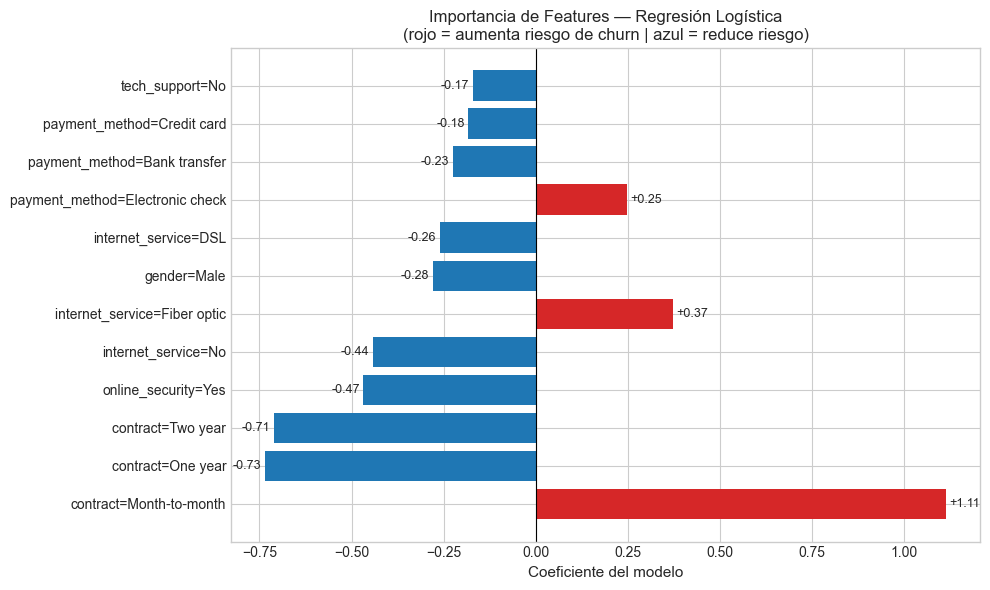

In [25]:
# ─── Visualizar los coeficientes más importantes ─────────────────────────────
top = importancia.head(12)
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top['coef']]  # rojo=riesgo, azul=protección

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top['feature'], top['coef'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente del modelo', fontsize=11)
ax.set_title('Importancia de Features — Regresión Logística\n(rojo = aumenta riesgo de churn | azul = reduce riesgo)', fontsize=12)

# Etiquetas de valores
for bar, val in zip(bars, top['coef']):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
# ─── Predecir para un cliente específico ─────────────────────────────────────
# Esta es la parte más práctica: usar el modelo entrenado para tomar decisiones

# Cliente de ALTO RIESGO: contrato mensual, recién ingresado, pago electrónico
cliente_riesgo = {
    'contract':        'Month-to-month',  # contrato mensual → factor de riesgo
    'tenure':          3,                  # solo 3 meses como cliente
    'monthly_charges': 75.0,
    'total_charges':   225.0,
    'internet_service':'Fiber optic',      # fibra → factor de riesgo
    'online_security': 'No',               # sin seguridad → factor de riesgo
    'tech_support':    'No',
    'payment_method':  'Electronic check', # cheque electrónico → factor de riesgo
    'gender':          'Male',
}

# Cliente de BAJO RIESGO: contrato largo, cliente antiguo
cliente_seguro = {
    'contract':        'Two year',         # contrato largo → protección
    'tenure':          60,                  # 5 años como cliente → alta fidelidad
    'monthly_charges': 45.0,
    'total_charges':   2700.0,
    'internet_service':'DSL',
    'online_security': 'Yes',               # con seguridad → protección
    'tech_support':    'Yes',
    'payment_method':  'Bank transfer',
    'gender':          'Female',
}

for nombre, cliente in [("🔴 Cliente de ALTO RIESGO", cliente_riesgo),
                         ("🟢 Cliente de BAJO RIESGO", cliente_seguro)]:
    X_cliente = dv.transform([cliente])
    prob      = modelo.predict_proba(X_cliente)[0, 1]
    decision  = '⚠️  CHURN PROBABLE' if prob >= 0.5 else '✅  CLIENTE ESTABLE'
    print(f"{nombre}")
    print(f"  Probabilidad de churn: {prob:.1%}")
    print(f"  Decisión del modelo:   {decision}")
    print()

🔴 Cliente de ALTO RIESGO
  Probabilidad de churn: 76.2%
  Decisión del modelo:   ⚠️  CHURN PROBABLE

🟢 Cliente de BAJO RIESGO
  Probabilidad de churn: 2.3%
  Decisión del modelo:   ✅  CLIENTE ESTABLE



## 7. Resumen y Conceptos Clave

### Lo que aprendiste en este notebook

| Concepto | Descripción |
|---|---|
| **Clasificación binaria** | Predecir una de dos clases (churn / no-churn) |
| **Target** | Variable a predecir (aquí: `churn`) |
| **Train / Val / Test** | Separación de datos para entrenar, ajustar y evaluar |
| **Risk Ratio** | Compara la tasa de churn por categoría vs. la global |
| **Información Mutua** | Cuánto "sabe" una variable categórica sobre el target |
| **One-Hot Encoding** | Convierte categorías en columnas binarias |
| **DictVectorizer** | Herramienta de scikit-learn para OHE desde diccionarios |
| **Función sigmoide** | Transforma $z \in (-\infty, +\infty)$ a probabilidad $[0,1]$ |
| **Regresión Logística** | Modelo lineal + sigmoide para clasificación |
| **Coeficientes** | Indican qué features aumentan o reducen el riesgo |
| **Accuracy** | % de predicciones correctas |
| **AUC-ROC** | Capacidad del modelo de ordenar churn vs no-churn (0.5=azar, 1=perfecto) |
| **Modelo Dummy** | Línea base que predice siempre la clase mayoritaria |

### Preguntas para reflexionar
1. ¿Por qué el `DictVectorizer` se ajusta solo con datos de entrenamiento y no con los de validación?
2. ¿Qué pasaría si bajaras el umbral de decisión de 0.5 a 0.3? ¿En qué casos conviene hacerlo?
3. ¿Por qué `tenure` tiene correlación negativa con churn? ¿Tiene sentido de negocio?
4. ¿Qué variable categórica es la más informativa según la Información Mutua? ¿Coincide con el Risk Ratio?

### Próximos pasos
- **Módulo 5:** Métricas de evaluación avanzadas (matriz de confusión, precisión, recall, curva ROC)
- **Módulo 6:** Árboles de decisión y ensambles (Random Forest, XGBoost)